imports and setup

In [6]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DATA_ROOT = Path("dataset_celeba")
IMG_DIR = DATA_ROOT / "img_align_celeba" / "img_align_celeba"
ATTR_FILE = DATA_ROOT / "list_attr_celeba.csv"
PART_FILE = DATA_ROOT / "list_eval_partition.csv"
OUT_DIR = Path("outputs_wgan")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "uncond").mkdir(exist_ok=True)
(OUT_DIR / "cond").mkdir(exist_ok=True)
IMG_SIZE = 64
LATENT_DIM = 128
CLASS_EMB = 32
N_FILTERS = 32
N_CRITIC = 3
LAMBDA_GP = 10
BATCH_SIZE = 64
LR = 2e-4
BETAS = (0.0, 0.9)
N_ITERS_UNCOND = 12_000
N_ITERS_COND = 8_000
SAVE_EVERY = 2_000
LOG_EVERY = 200
NUM_CLASSES = 2
N_FID = 5_000
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"
DEVICE = get_device()
print(f"device: {DEVICE}")

device: mps


celeba dataset — gender label from list_attr_celeba.csv (male=1, female=0)

train: 162770  male: 68261  female: 94509


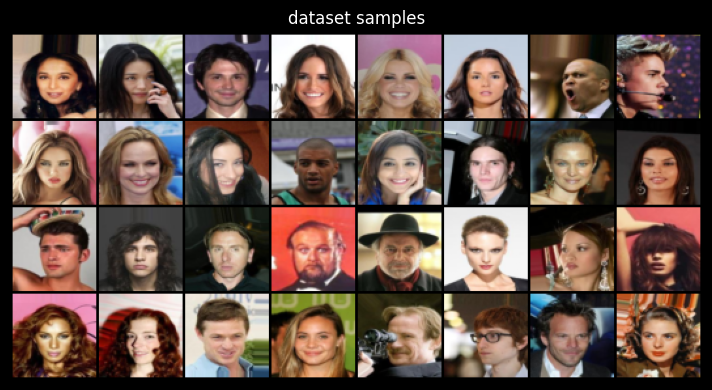

-> outputs_wgan/dataset_samples.png


In [7]:
class CelebAFaceDataset(Dataset):
    def __init__(self, face_dir, attr_file, part_file, split="train"):
        split_id = {"train": 0, "val": 1, "test": 2}[split]
        part_df = pd.read_csv(part_file)
        attr_df = pd.read_csv(attr_file)
        df = part_df.merge(attr_df[["image_id", "Male"]], on="image_id")
        df = df[df["partition"] == split_id].reset_index(drop=True)
        proc_names = {p.name for p in Path(face_dir).glob("*.jpg")}
        df = df[df["image_id"].isin(proc_names)].reset_index(drop=True)
        self.face_dir = Path(face_dir)
        self.image_ids = df["image_id"].tolist()
        self.labels = (df["Male"] == 1).astype(int).tolist()
        self.transform = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
    def __len__(self):
        return len(self.image_ids)
    def __getitem__(self, idx):
        img = Image.open(self.face_dir / self.image_ids[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]
train_ds = CelebAFaceDataset(IMG_DIR, ATTR_FILE, PART_FILE, split="train")
male_n = sum(train_ds.labels)
print(f"train: {len(train_ds)}  male: {male_n}  female: {len(train_ds)-male_n}")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(DEVICE=="cuda"), drop_last=True)
imgs, labels = next(iter(train_loader))
grid = vutils.make_grid(imgs[:32], normalize=True, value_range=(-1, 1), nrow=8)
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title("dataset samples")
ax.axis("off")
fig.tight_layout()
out = OUT_DIR / "dataset_samples.png"
fig.savefig(out, dpi=110)
plt.show()
print(f"-> {out}")

model architectures — wgan-gp generator and critic

In [8]:
def weights_init(m):
    cls = type(m).__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, ngf=N_FILTERS):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z.view(z.size(0), -1, 1, 1))
class Critic(nn.Module):
    def __init__(self, ndf=N_FILTERS):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
        )
        self.head = nn.Linear(ndf * 8 * 4 * 4, 1)
    def forward(self, x):
        return self.head(self.features(x).view(x.size(0), -1))
def compute_gp(critic, real, fake, device, labels=None):
    B = real.size(0)
    alpha = torch.rand(B, 1, 1, 1, device=device)
    interp = (alpha * real.detach() + (1 - alpha) * fake.detach()).requires_grad_(True)
    d_interp = critic(interp) if labels is None else critic(interp, labels)
    grad = torch.autograd.grad(outputs=d_interp, inputs=interp, grad_outputs=torch.ones_like(d_interp), create_graph=True, retain_graph=True, only_inputs=True)[0]
    return ((grad.view(B, -1).norm(2, dim=1) - 1) ** 2).mean()
z_t = torch.randn(4, LATENT_DIM)
g_t, d_t = Generator(), Critic()
out_g = g_t(z_t)
print(f"generator:  z {tuple(z_t.shape)} -> img {tuple(out_g.shape)}")
print(f"critic:     img {tuple(out_g.shape)} -> score {tuple(d_t(out_g).shape)}")
del g_t, d_t, z_t, out_g

generator:  z (4, 128) -> img (4, 3, 64, 64)
critic:     img (4, 3, 64, 64) -> score (4, 1)


training helper — wgan-gp loop (unconditional and conditional)

In [9]:
import json
def train_wgan_gp(dataloader, n_iters, save_dir, G, D, conditional=False):
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    ckpt_path = save_dir / "checkpoint.pt"
    losses_path = save_dir / "losses.json"
    opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
    opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)
    fixed_z = torch.randn(64, LATENT_DIM, device=DEVICE)
    fixed_lbl = torch.tensor([i % NUM_CLASSES for i in range(64)], device=DEVICE)
    G_losses, D_losses = [], []
    start_it = 1
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        G.load_state_dict(ckpt["G"])
        D.load_state_dict(ckpt["D"])
        opt_G.load_state_dict(ckpt["opt_G"])
        opt_D.load_state_dict(ckpt["opt_D"])
        G_losses = ckpt["G_losses"]
        D_losses = ckpt["D_losses"]
        start_it = ckpt["it"] + 1
        print(f"resuming from iteration {ckpt['it']}/{n_iters}")
    if start_it > n_iters:
        print(f"already completed {n_iters} iterations")
        if not losses_path.exists():
            with open(losses_path, "w") as f:
                json.dump({"G": G_losses, "D": D_losses}, f)
        return G, D, G_losses, D_losses
    data_iter = iter(dataloader)
    pbar = tqdm(range(start_it, n_iters + 1))
    for it in pbar:
        G.train(); D.train()
        loss_D_val = 0.0
        for _ in range(N_CRITIC):
            try:
                real, lbls = next(data_iter)
            except StopIteration:
                data_iter = iter(dataloader)
                real, lbls = next(data_iter)
            real = real.to(DEVICE)
            lbls = lbls.to(DEVICE)
            B = real.size(0)
            z = torch.randn(B, LATENT_DIM, device=DEVICE)
            with torch.no_grad():
                fake = G(z, lbls) if conditional else G(z)
            d_real = D(real, lbls) if conditional else D(real)
            d_fake = D(fake, lbls) if conditional else D(fake)
            gp = compute_gp(D, real, fake, DEVICE, labels=lbls if conditional else None)
            loss_D = d_fake.mean() - d_real.mean() + LAMBDA_GP * gp
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()
            loss_D_val = loss_D.item()
        z = torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE)
        lbl_g = torch.randint(0, NUM_CLASSES, (BATCH_SIZE,), device=DEVICE)
        fake = G(z, lbl_g) if conditional else G(z)
        loss_G = -(D(fake, lbl_g) if conditional else D(fake)).mean()
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
        G_losses.append(loss_G.item())
        D_losses.append(loss_D_val)
        if it % LOG_EVERY == 0:
            pbar.set_postfix({"D": f"{loss_D_val:.3f}", "G": f"{loss_G.item():.3f}"})
        if it % SAVE_EVERY == 0 or it == n_iters:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z, fixed_lbl) if conditional else G(fixed_z)
            grid = vutils.make_grid(samples, normalize=True, value_range=(-1, 1), nrow=8)
            vutils.save_image(grid, save_dir / f"iter_{it:06d}.png")
            torch.save({
                "it": it,
                "G": G.state_dict(),
                "D": D.state_dict(),
                "opt_G": opt_G.state_dict(),
                "opt_D": opt_D.state_dict(),
                "G_losses": G_losses,
                "D_losses": D_losses,
            }, ckpt_path)
            G.train()
    with open(losses_path, "w") as f:
        json.dump({"G": G_losses, "D": D_losses}, f)
    return G, D, G_losses, D_losses

unconditional wgan-gp — 12 000 iterations

In [10]:
G_uncond = Generator().to(DEVICE)
D_uncond = Critic().to(DEVICE)
final_g = OUT_DIR / "G_uncond.pth"
final_d = OUT_DIR / "D_uncond.pth"
losses_path = OUT_DIR / "uncond" / "losses.json"
if final_g.exists() and final_d.exists() and losses_path.exists():
    G_uncond.load_state_dict(torch.load(final_g, map_location=DEVICE, weights_only=True))
    with open(losses_path) as f:
        _ld = json.load(f)
    G_losses_u, D_losses_u = _ld["G"], _ld["D"]
    print(f"loaded trained G_uncond from {final_g}")
else:
    G_uncond.apply(weights_init)
    D_uncond.apply(weights_init)
    G_uncond, D_uncond, G_losses_u, D_losses_u = train_wgan_gp(train_loader, N_ITERS_UNCOND, save_dir=OUT_DIR / "uncond", G=G_uncond, D=D_uncond, conditional=False)
    torch.save(G_uncond.state_dict(), final_g)
    torch.save(D_uncond.state_dict(), final_d)
    print(f"-> {final_g}")

loaded trained G_uncond from outputs_wgan/G_uncond.pth


unconditional samples

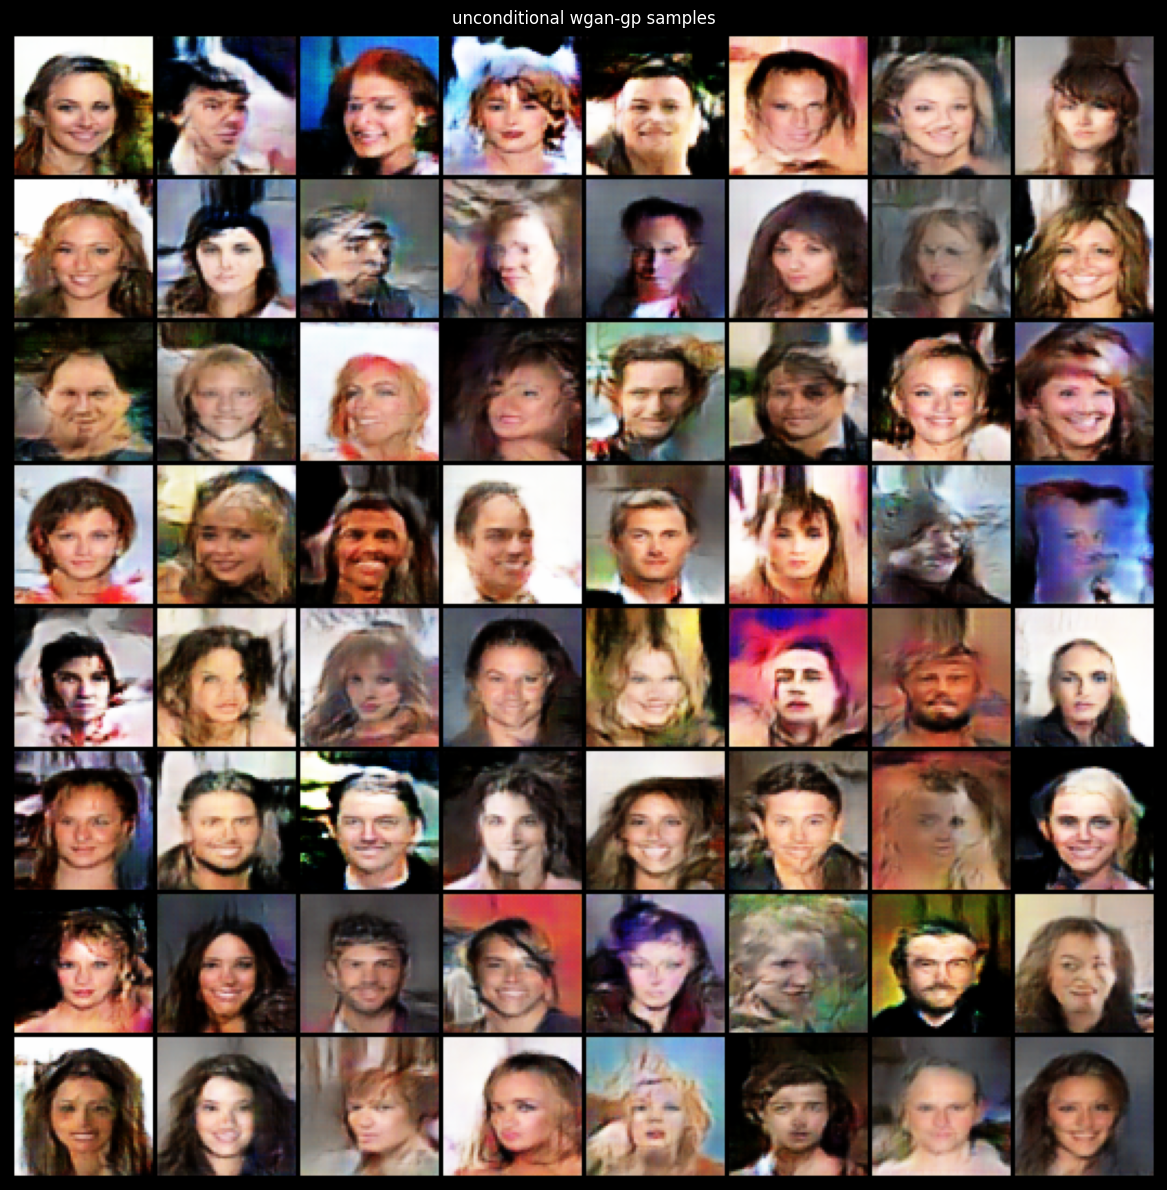

-> outputs_wgan/uncond_final.png


In [11]:
G_uncond.eval()
with torch.no_grad():
    gen_imgs = G_uncond(torch.randn(64, LATENT_DIM, device=DEVICE))
grid = vutils.make_grid(gen_imgs, normalize=True, value_range=(-1, 1), nrow=8)
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
ax.set_title("unconditional wgan-gp samples")
ax.axis("off")
fig.tight_layout()
out = OUT_DIR / "uncond_final.png"
fig.savefig(out, dpi=100)
plt.show()
print(f"-> {out}")

conditional wgan-gp — projection discriminator (miyato & koyama, 2018)

In [12]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, class_emb=CLASS_EMB, num_classes=NUM_CLASSES, ngf=N_FILTERS):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, class_emb)
        in_ch = latent_dim + class_emb
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_ch, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z, labels):
        zc = torch.cat([z, self.class_emb(labels)], dim=1)
        return self.net(zc.view(zc.size(0), -1, 1, 1))
class ConditionalCritic(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, ndf=N_FILTERS):
        super().__init__()
        feat_dim = ndf * 8 * 4 * 4
        self.features = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(feat_dim, 1)
        self.emb = nn.Embedding(num_classes, feat_dim)
    def forward(self, x, labels):
        h = self.features(x).view(x.size(0), -1)
        return self.fc(h) + (h * self.emb(labels)).sum(dim=1, keepdim=True)
z_t, lbl_t = torch.randn(4, LATENT_DIM), torch.randint(0, 2, (4,))
cg_t, cd_t = ConditionalGenerator(), ConditionalCritic()
out_cg = cg_t(z_t, lbl_t)
print(f"cond generator: [z, label] -> {tuple(out_cg.shape)}")
print(f"cond critic:    img + label -> {tuple(cd_t(out_cg, lbl_t).shape)}")
del cg_t, cd_t, z_t, lbl_t, out_cg

cond generator: [z, label] -> (4, 3, 64, 64)
cond critic:    img + label -> (4, 1)


train conditional model — gender conditioning (8 000 iterations)

In [13]:
G_cond = ConditionalGenerator().to(DEVICE)
D_cond = ConditionalCritic().to(DEVICE)
final_g = OUT_DIR / "G_cond.pth"
final_d = OUT_DIR / "D_cond.pth"
losses_path = OUT_DIR / "cond" / "losses.json"
if final_g.exists() and final_d.exists() and losses_path.exists():
    G_cond.load_state_dict(torch.load(final_g, map_location=DEVICE, weights_only=True))
    with open(losses_path) as f:
        _ld = json.load(f)
    G_losses_c, D_losses_c = _ld["G"], _ld["D"]
    print(f"loaded trained G_cond from {final_g}")
else:
    G_cond.apply(weights_init)
    D_cond.apply(weights_init)
    G_cond, D_cond, G_losses_c, D_losses_c = train_wgan_gp(train_loader, N_ITERS_COND, save_dir=OUT_DIR / "cond", G=G_cond, D=D_cond, conditional=True)
    torch.save(G_cond.state_dict(), final_g)
    torch.save(D_cond.state_dict(), final_d)
    print(f"-> {final_g}")

loaded trained G_cond from outputs_wgan/G_cond.pth


conditional samples — same noise, female (0) vs male (1)

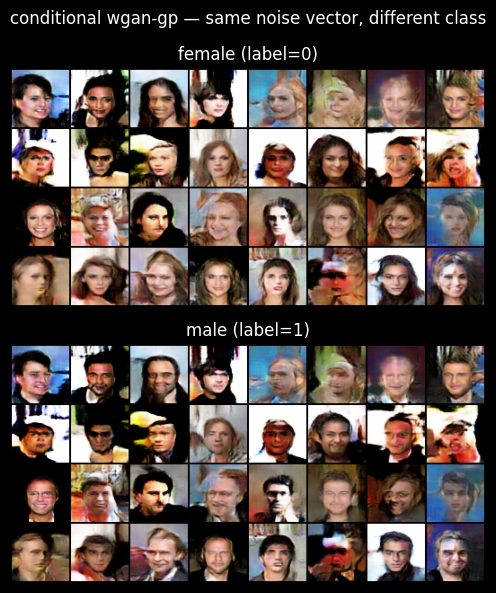

-> outputs_wgan/cond_final.png


In [14]:
G_cond.eval()
with torch.no_grad():
    z_show = torch.randn(32, LATENT_DIM, device=DEVICE)
    imgs_f = G_cond(z_show, torch.zeros(32, dtype=torch.long, device=DEVICE))
    imgs_m = G_cond(z_show, torch.ones(32, dtype=torch.long, device=DEVICE))
fig, axes = plt.subplots(2, 1, figsize=(16, 6))
for ax, imgs, title in zip(axes, [imgs_f, imgs_m], ["female (label=0)", "male (label=1)"]):
    grid = vutils.make_grid(imgs, normalize=True, value_range=(-1, 1), nrow=8)
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("conditional wgan-gp — same noise vector, different class")
fig.tight_layout()
out = OUT_DIR / "cond_final.png"
fig.savefig(out, dpi=100)
plt.show()
print(f"-> {out}")

metrics — fid (lower is better) and is (higher is better)

In [16]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
def to_uint8(t):
    return ((t.clamp(-1, 1) + 1) / 2 * 255).to(torch.uint8)
@torch.no_grad()
def compute_metrics(generator, dataloader, n_samples=N_FID, conditional=False, label=None):
    fid_m = FrechetInceptionDistance(feature=2048).to(DEVICE)
    is_m = InceptionScore(normalize=False).to(DEVICE)
    generator.eval()
    n_real = 0
    for imgs, lbls in dataloader:
        if n_real >= n_samples:
            break
        if conditional and label is not None:
            imgs = imgs[lbls == label]
        if imgs.size(0) == 0:
            continue
        fid_m.update(to_uint8(imgs.to(DEVICE)), real=True)
        n_real += imgs.size(0)
    n_gen = 0
    while n_gen < n_samples:
        B = min(BATCH_SIZE, n_samples - n_gen)
        z = torch.randn(B, LATENT_DIM, device=DEVICE)
        lbl = torch.full((B,), label if label is not None else 0, dtype=torch.long, device=DEVICE)
        fake = generator(z, lbl) if conditional else generator(z)
        fake_u8 = to_uint8(fake)
        fid_m.update(fake_u8, real=False)
        is_m.update(fake_u8)
        n_gen += B
    fid_val = fid_m.compute().item()
    is_mean, is_std = is_m.compute()
    return fid_val, is_mean.item(), is_std.item()
def print_metrics(name, fid, is_mean, is_std):
    print(f"\n{'─'*40}\n  {name}\n{'─'*40}")
    print(f"  {'fid':<20} {fid:.2f}   (lower is better)")
    print(f"  {'is':<20} {is_mean:.3f} ± {is_std:.3f}   (higher is better)")
    print(f"{'─'*40}")
metrics_cache = OUT_DIR / "metrics.json"
if metrics_cache.exists():
    with open(metrics_cache) as f:
        _mc = json.load(f)
    fid_u, is_u_mean, is_u_std = _mc["uncond"]["fid"], _mc["uncond"]["is_mean"], _mc["uncond"]["is_std"]
    fid_cf, is_cf_mean, is_cf_std = _mc["cond_f"]["fid"], _mc["cond_f"]["is_mean"], _mc["cond_f"]["is_std"]
    fid_cm, is_cm_mean, is_cm_std = _mc["cond_m"]["fid"], _mc["cond_m"]["is_mean"], _mc["cond_m"]["is_std"]
    print("loaded cached metrics")
else:
    print("computing fid and is ...")
    fid_u, is_u_mean, is_u_std = compute_metrics(G_uncond, train_loader, conditional=False)
    fid_cf, is_cf_mean, is_cf_std = compute_metrics(G_cond, train_loader, conditional=True, label=0)
    fid_cm, is_cm_mean, is_cm_std = compute_metrics(G_cond, train_loader, conditional=True, label=1)
    with open(metrics_cache, "w") as f:
        json.dump({
            "uncond": {"fid": fid_u, "is_mean": is_u_mean, "is_std": is_u_std},
            "cond_f": {"fid": fid_cf, "is_mean": is_cf_mean, "is_std": is_cf_std},
            "cond_m": {"fid": fid_cm, "is_mean": is_cm_mean, "is_std": is_cm_std},
        }, f, indent=2)
    print(f"saved -> {metrics_cache}")
print_metrics("unconditional wgan-gp", fid_u, is_u_mean, is_u_std)
print_metrics("conditional wgan-gp  female (0)", fid_cf, is_cf_mean, is_cf_std)
print_metrics("conditional wgan-gp  male   (1)", fid_cm, is_cm_mean, is_cm_std)

computing fid and is ...


/Users/zji25/PycharmProjects/comp-vision/.venv/lib/python3.14/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


saved -> outputs_wgan/metrics.json

────────────────────────────────────────
  unconditional wgan-gp
────────────────────────────────────────
  fid                  62.65   (lower is better)
  is                   2.659 ± 0.086   (higher is better)
────────────────────────────────────────

────────────────────────────────────────
  conditional wgan-gp  female (0)
────────────────────────────────────────
  fid                  61.26   (lower is better)
  is                   2.322 ± 0.040   (higher is better)
────────────────────────────────────────

────────────────────────────────────────
  conditional wgan-gp  male   (1)
────────────────────────────────────────
  fid                  72.72   (lower is better)
  is                   2.628 ± 0.092   (higher is better)
────────────────────────────────────────


training curves

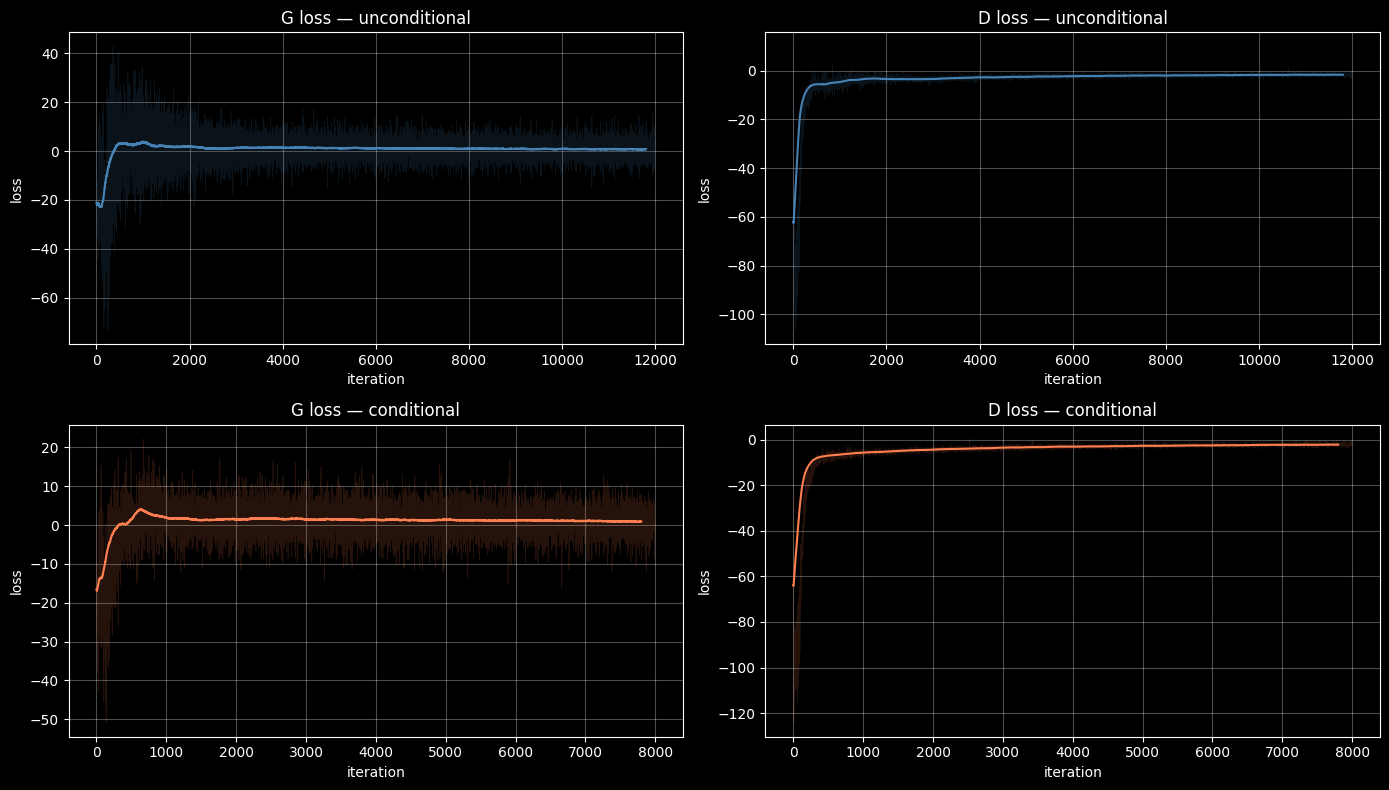

-> outputs_wgan/training_curves.png


In [17]:
def smooth(x, w=200):
    return np.convolve(x, np.ones(w) / w, mode="valid")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    (axes[0, 0], G_losses_u, "G loss — unconditional", "steelblue"),
    (axes[0, 1], D_losses_u, "D loss — unconditional", "steelblue"),
    (axes[1, 0], G_losses_c, "G loss — conditional", "coral"),
    (axes[1, 1], D_losses_c, "D loss — conditional", "coral"),
]
for ax, losses, title, color in pairs:
    ax.plot(losses, alpha=0.15, color=color, linewidth=0.5)
    if len(losses) > 200:
        ax.plot(smooth(losses), color=color, linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
out = OUT_DIR / "training_curves.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"-> {out}")

results summary

In [18]:
import json
summary = {
    "unconditional": {
        "fid": round(fid_u, 2),
        "is_mean": round(is_u_mean, 3),
        "is_std": round(is_u_std, 3),
    },
    "conditional_female": {
        "fid": round(fid_cf, 2),
        "is_mean": round(is_cf_mean, 3),
        "is_std": round(is_cf_std, 3),
    },
    "conditional_male": {
        "fid": round(fid_cm, 2),
        "is_mean": round(is_cm_mean, 3),
        "is_std": round(is_cm_std, 3),
    },
}
for model, vals in summary.items():
    print(f"  {model:<28} fid={vals['fid']:.2f}  is={vals['is_mean']:.3f}±{vals['is_std']:.3f}")
out = OUT_DIR / "summary.json"
with open(out, "w") as f:
    json.dump(summary, f, indent=2)
print(f"-> {out}")

  unconditional                fid=62.65  is=2.659±0.086
  conditional_female           fid=61.26  is=2.322±0.040
  conditional_male             fid=72.72  is=2.628±0.092
-> outputs_wgan/summary.json


## вывод

обучили wgan-gp на датасете celeba, 202599 лиц, в два этапа

предобработка

лица в celeba уже выровнены и обрезаны, изображения 178x218 масштабируются до 64x64 через T.Resize

безусловная генерация

wgan-gp с градиентным штрафом λ=10 обучался 12000 итераций, критик обновлялся 3 раза на одно обновление генератора. по сравнению с ванильным gan нет коллапса мод и лоссы не расходятся

условная генерация

проекционный дискриминатор из работы miyato & koyama 2018 задаёт условие через скалярное произведение признаков и классового эмбеддинга, это стабильнее простой конкатенации. при одинаковом векторе шума z модель генерирует разные мужские и женские лица. обучалась 8000 итераций

метрики на 5000 сгенерированных изображений:

| модель | fid ↓ | is ↑ |
|---|---|---|
| безусловная | 62.65 | 2.659 ± 0.086 |
| условная female | 61.26 | 2.322 ± 0.040 |
| условная male | 72.72 | 2.628 ± 0.092 |

fid у female-модели даже ниже безусловной: скорее всего женских лиц в датасете больше и распределение класса чище. fid у male-модели хуже: примеров на класс меньше. is у female-модели ниже что логично: внутри одного пола меньше разнообразия. у male is близко к безусловной